# GSE211692 EDA and statistics to complement the neural network

This notebook is structured to **complement** a separate neural-network analysis by focusing on:

- metadata and sample-level QC
- sample-level expression EDA
- PCA / unsupervised structure
- **per-miRNA** differential testing
- multiple-testing correction
- interpretable visualizations (volcano plot, heatmap, boxplots)

> Important fix: do **not** pool all miRNA expression values together and run one test on the melted long table.  
> The unit of inference should be **samples across each miRNA**, not all measurements collapsed together.


## 1) Import Libraries

In [34]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from scipy.stats import kruskal

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


## 2) Load data

In [3]:

large_df = pd.read_csv('/Users/kevindai/downloads/GSE211692_processed_data_matrix.txt', sep="\t", index_col=0)
meta_df = pd.read_csv('/Users/kevindai/downloads/GSE211692_metadata.csv')

print("Expression matrix shape:", large_df.shape)
print("Metadata shape:", meta_df.shape)
meta_df.head()


Expression matrix shape: (2565, 16190)
Metadata shape: (16190, 5)


,Sample ID,Title,Disease State,Gender,Age
0,GSM6483171,BC0010,breast cancer,Female,64
1,GSM6483172,BC0011,breast cancer,Female,47
2,GSM6483173,BC0016,breast cancer,Female,39
3,GSM6483174,BC0025,breast cancer,Female,36
4,GSM6483175,BC0033,breast cancer,Female,44


## 3) Metadata QC and cleanup

In [4]:
meta_df = meta_df.copy()

# Basic cleanup
meta_df["Age"] = pd.to_numeric(meta_df["Age"], errors="coerce")
meta_df["Disease State"] = meta_df["Disease State"].astype(str).str.strip()
meta_df["Gender"] = meta_df["Gender"].astype(str).str.strip()
meta_df["Title"] = meta_df["Title"].astype(str).str.strip()

# Normalize benign labels into a shared control label
meta_df["Disease State"] = meta_df["Disease State"].replace(
    to_replace=r"(?i).*benign.*", value="no cancer", regex=True
)

# Optional: normalize a few obvious variants if present
meta_df["Disease State"] = meta_df["Disease State"].replace({
    "healthy": "no cancer",
    "control": "no cancer",
    "non-cancer": "no cancer",
})

print("Missing values by metadata column:")
display(meta_df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows in metadata:", meta_df.duplicated().sum())
print("Unique disease states:", meta_df["Disease State"].nunique())
meta_df["Disease State"].value_counts().head(20)


Missing values by metadata column:


Age              5
Sample ID        0
Title            0
Disease State    0
Gender           0
dtype: int64


Duplicate rows in metadata: 0
Unique disease states: 14


Disease State
no cancer                          6269
lung cancer                        1699
colorectal cancer                  1596
gastric cancer                     1418
prostate cancer                    1027
pancreatic cancer                   851
breast cancer                       675
esophageal squamous cell cancer     566
biliary tract cancer                402
ovarian cancer                      400
bladder cancer                      399
hepatocellular cancer               348
bone and soft tissue sarcomas       299
intraparenchymal brain tumors       241
Name: count, dtype: int64

In [5]:
meta_df

,Sample ID,Title,Disease State,Gender,Age
0,GSM6483171,BC0010,breast cancer,Female,64.0
1,GSM6483172,BC0011,breast cancer,Female,47.0
2,GSM6483173,BC0016,breast cancer,Female,39.0
3,GSM6483174,BC0025,breast cancer,Female,36.0
4,GSM6483175,BC0033,breast cancer,Female,44.0
...,...,...,...,...,...
16185,GSM6499356,XB0996,no cancer,Male,36.0
16186,GSM6499357,XB0997,no cancer,Male,35.0
16187,GSM6499358,XB0998,no cancer,Male,35.0
16188,GSM6499359,XB0999,no cancer,Male,39.0


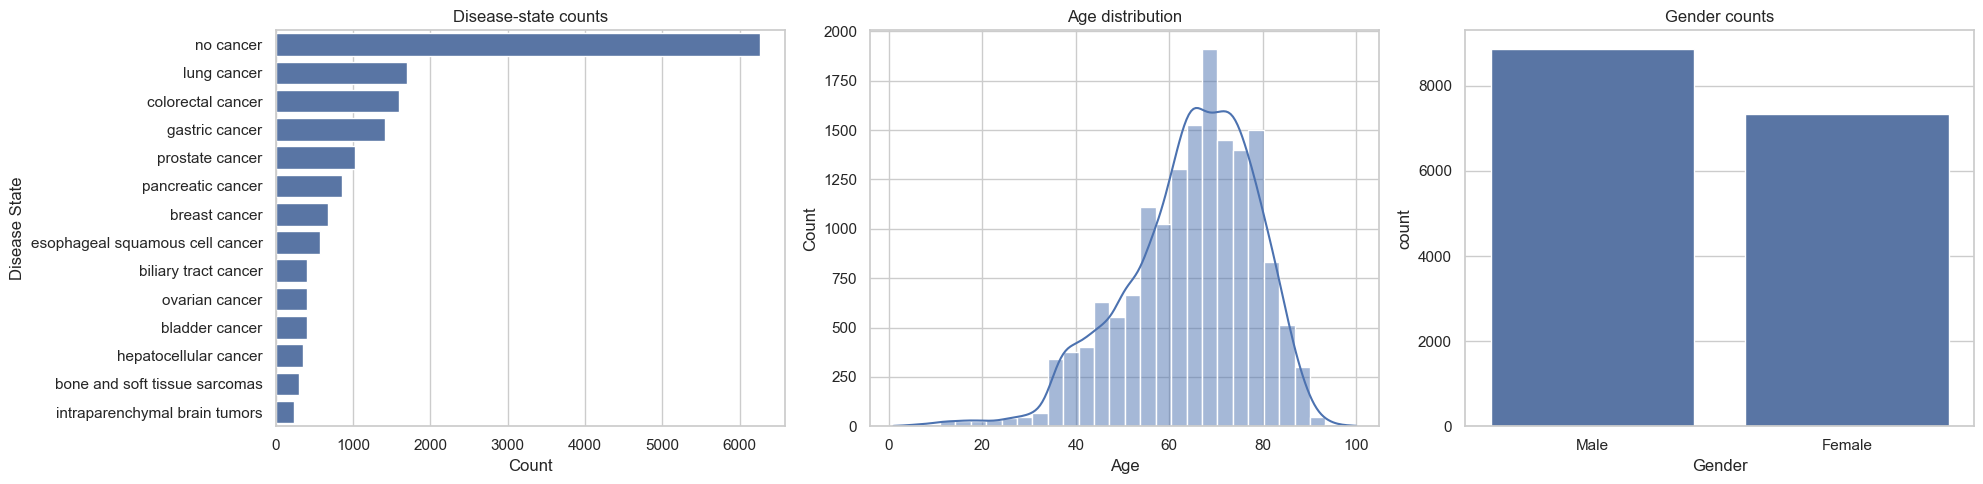

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(
    data=meta_df,
    y="Disease State",
    order=meta_df["Disease State"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Disease-state counts")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Disease State")

sns.histplot(data=meta_df, x="Age", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Age distribution")

gender_order = meta_df["Gender"].value_counts().index
sns.countplot(data=meta_df, x="Gender", order=gender_order, ax=axes[2])
axes[2].set_title("Gender counts")

plt.tight_layout()
plt.show()


## 4) Merge metadata and expression matrix

This keeps **samples** as rows and **miRNAs** as columns.


In [7]:

merged_df = meta_df.set_index("Title").join(large_df.T, how="inner")
merged_df.index.name = "Title"

meta_cols = [c for c in ["Disease State", "Age", "Gender", "Sample ID"] if c in merged_df.columns]
mirna_cols = [c for c in merged_df.columns if c not in meta_cols]

# Force expression columns to numeric
merged_df[mirna_cols] = merged_df[mirna_cols].apply(pd.to_numeric, errors="coerce")

print("Merged shape:", merged_df.shape)
print("Number of metadata columns:", len(meta_cols))
print("Number of miRNA features:", len(mirna_cols))
print("Samples retained after merge:", merged_df.shape[0])

display(merged_df[meta_cols].head())


Merged shape: (16190, 2569)
Number of metadata columns: 4
Number of miRNA features: 2565
Samples retained after merge: 16190


,Disease State,Age,Gender,Sample ID
Title,,,,
BC0010,breast cancer,64.0,Female,GSM6483171
BC0011,breast cancer,47.0,Female,GSM6483172
BC0016,breast cancer,39.0,Female,GSM6483173
BC0025,breast cancer,36.0,Female,GSM6483174
BC0033,breast cancer,44.0,Female,GSM6483175


## 5) Sample-level expression QC

These plots treat each **sample** as the observation unit.


,sample_median_expr,sample_iqr_expr,sample_missing_frac,Disease State,Age,Gender,Sample ID
Title,,,,,,,
BC0010,-1.177703,0.0,0.0,breast cancer,64.0,Female,GSM6483171
BC0011,-1.556806,0.0,0.0,breast cancer,47.0,Female,GSM6483172
BC0016,-1.321168,0.0,0.0,breast cancer,39.0,Female,GSM6483173
BC0025,-2.176251,0.0,0.0,breast cancer,36.0,Female,GSM6483174
BC0033,-2.079343,0.0,0.0,breast cancer,44.0,Female,GSM6483175


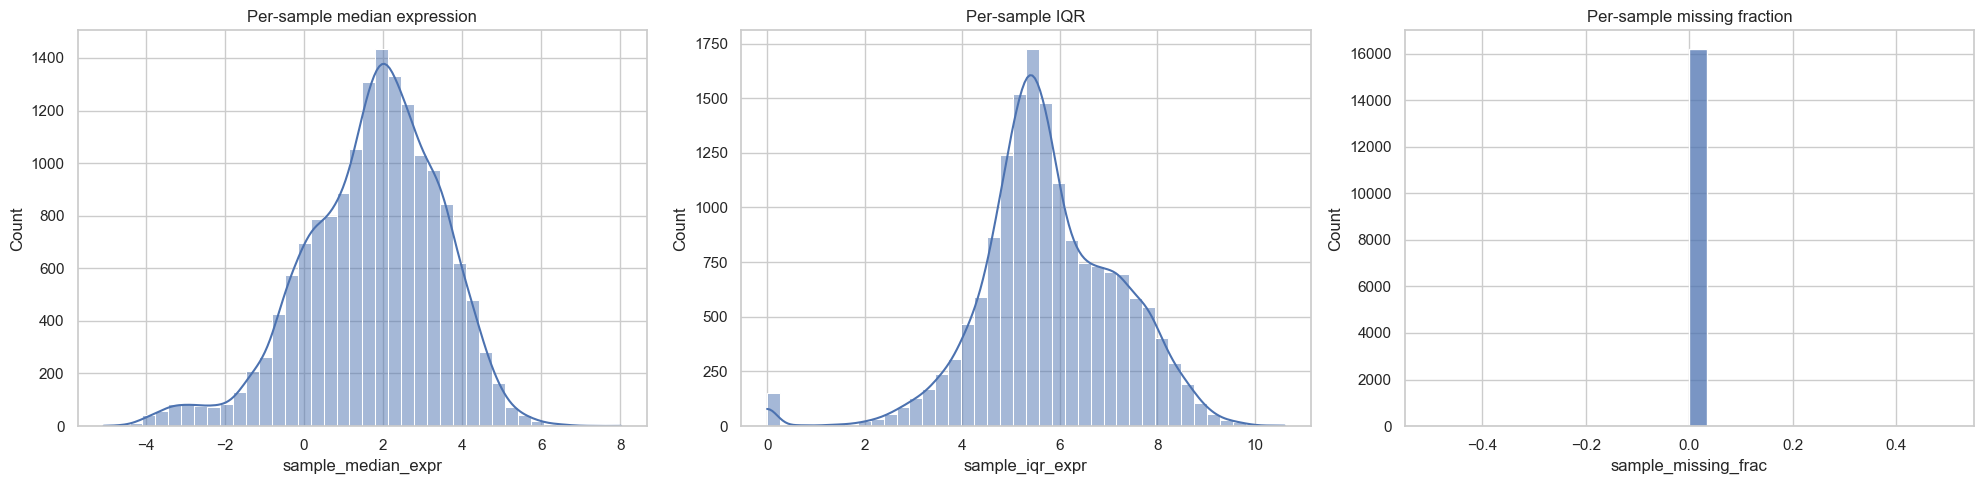

In [8]:

sample_qc = pd.DataFrame(index=merged_df.index)
sample_qc["sample_median_expr"] = merged_df[mirna_cols].median(axis=1, skipna=True)
sample_qc["sample_iqr_expr"] = merged_df[mirna_cols].quantile(0.75, axis=1) - merged_df[mirna_cols].quantile(0.25, axis=1)
sample_qc["sample_missing_frac"] = merged_df[mirna_cols].isna().mean(axis=1)
sample_qc = sample_qc.join(merged_df[meta_cols])

display(sample_qc.head())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(sample_qc["sample_median_expr"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Per-sample median expression")

sns.histplot(sample_qc["sample_iqr_expr"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Per-sample IQR")

sns.histplot(sample_qc["sample_missing_frac"], bins=30, kde=False, ax=axes[2])
axes[2].set_title("Per-sample missing fraction")

plt.tight_layout()
plt.show()


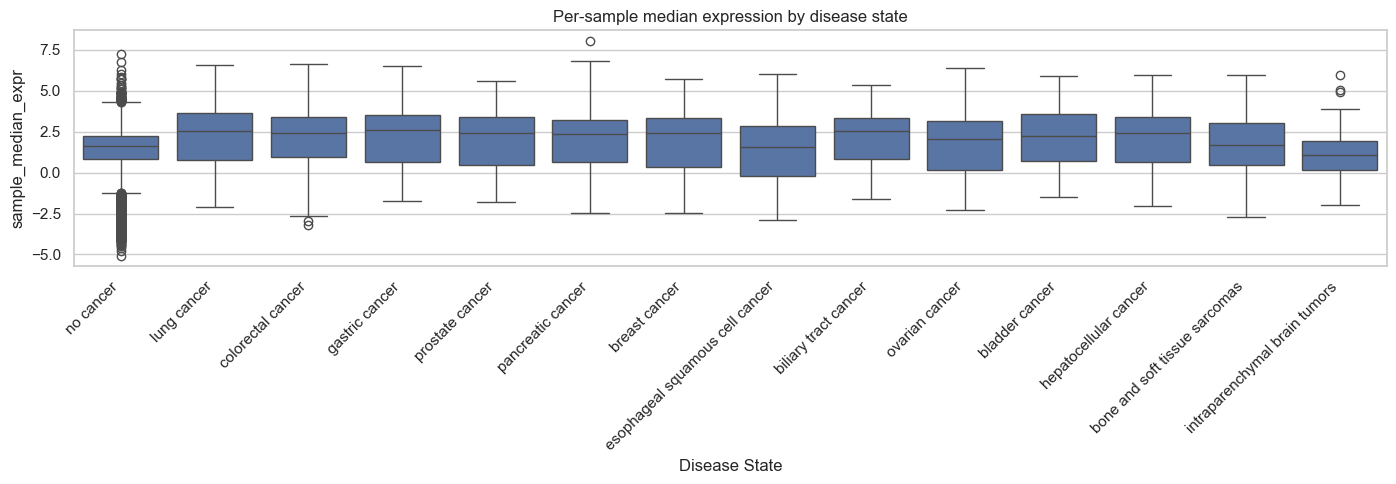

In [9]:

plt.figure(figsize=(14, 5))
top_order = merged_df["Disease State"].value_counts().index
sns.boxplot(
    data=sample_qc.reset_index(),
    x="Disease State",
    y="sample_median_expr",
    order=top_order
)
plt.xticks(rotation=45, ha="right")
plt.title("Per-sample median expression by disease state")
plt.tight_layout()
plt.show()


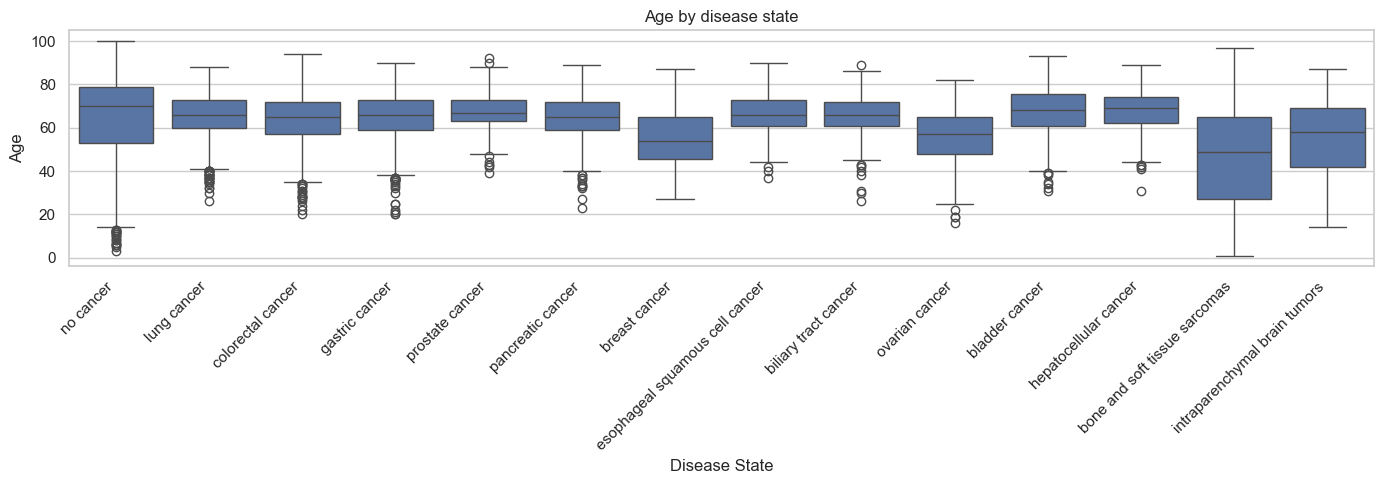

In [30]:
plt.figure(figsize=(14, 5))
order = merged_df["Disease State"].value_counts().index
sns.boxplot(
    data=merged_df,
    x="Disease State",
    y="Age",
    order=order
)

plt.xticks(rotation=45, ha="right")
plt.title("Age by disease state")
plt.tight_layout()
plt.show()

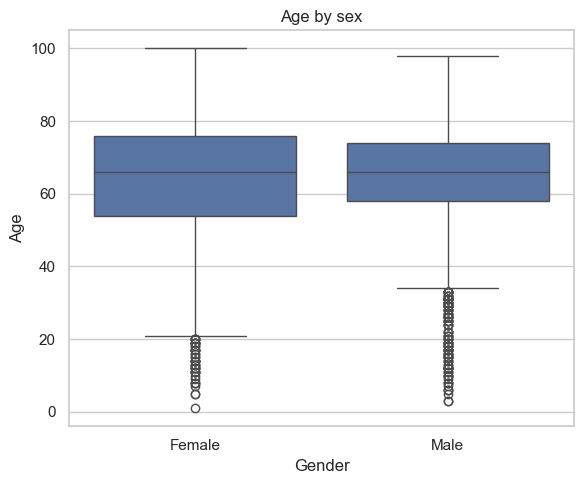

In [31]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=merged_df,
    x="Gender",
    y="Age"
)

plt.title("Age by sex")
plt.tight_layout()
plt.show()

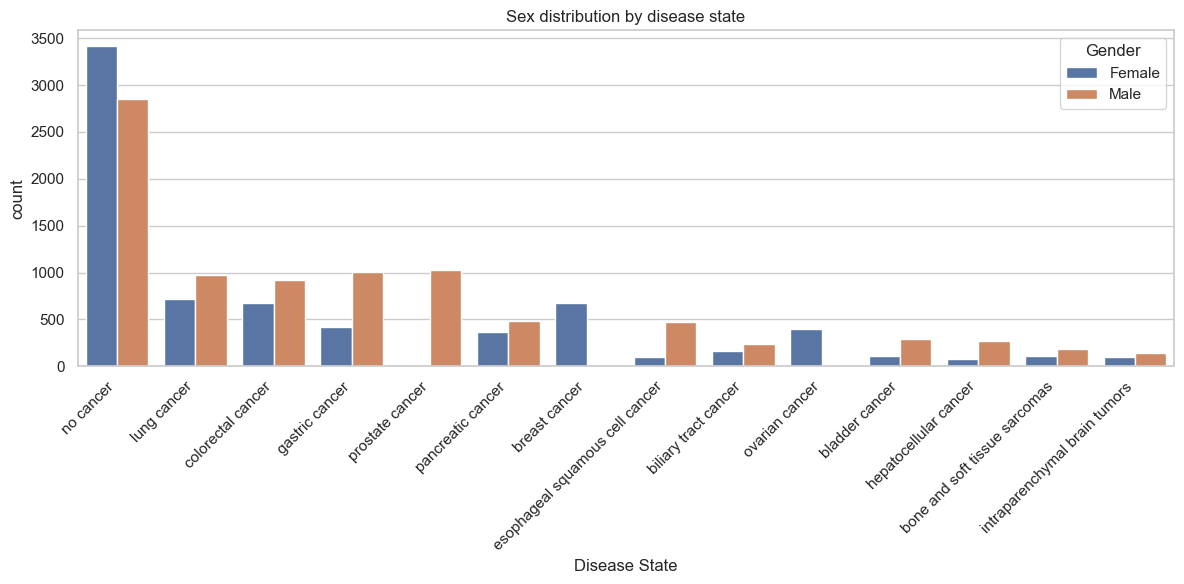

In [32]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=merged_df,
    x="Disease State",
    hue="Gender",
    order=merged_df["Disease State"].value_counts().index
)

plt.xticks(rotation=45, ha="right")
plt.title("Sex distribution by disease state")
plt.tight_layout()
plt.show()

## 6) PCA

PCA can show whether broad disease structure or batch/sex structure dominates.


Explained variance ratio: [0.26608217 0.07037082]


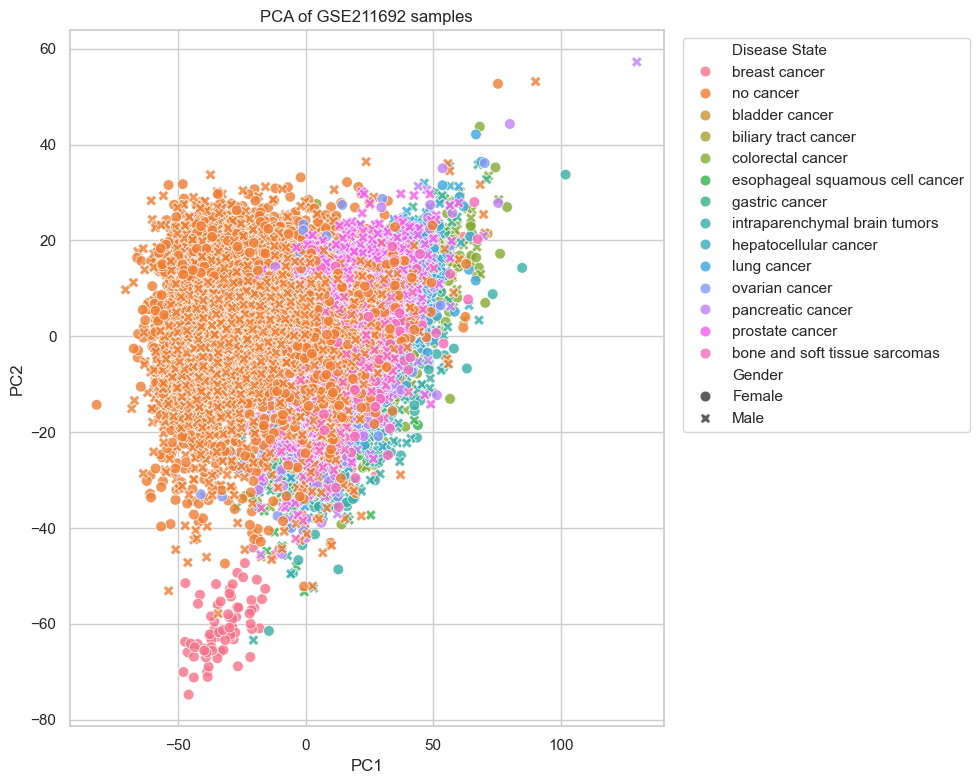

In [10]:

X = merged_df[mirna_cols].copy()

# Conservative imputation for PCA only
X_imputed = X.fillna(X.median())

# Standardize features for PCA
X_scaled = StandardScaler().fit_transform(X_imputed)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

pca_df = merged_df[meta_cols].copy()
pca_df["PC1"] = pcs[:, 0]
pca_df["PC2"] = pcs[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Disease State",
    style="Gender" if "Gender" in pca_df.columns else None,
    alpha=0.8,
    s=60
)
plt.title("PCA of GSE211692 samples")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 7) Per-miRNA differential testing

Here we compare **prostate cancer** vs **male no-cancer controls** on a **miRNA-by-miRNA** basis.
**prostate cancer** only appears in males so controls must be **male**


In [11]:

def rank_biserial_from_u(u_stat, n1, n2):
    # Effect size for Mann–Whitney U
    return 1 - (2 * u_stat) / (n1 * n2)

def per_mirna_mannwhitney(df, features, group_col, group_a, group_b, extra_mask=None):
    work = df.copy()
    if extra_mask is not None:
        work = work.loc[extra_mask].copy()

    a = work[work[group_col] == group_a]
    b = work[work[group_col] == group_b]

    rows = []
    for feat in features:
        xa = a[feat].dropna().values
        xb = b[feat].dropna().values

        if len(xa) < 3 or len(xb) < 3:
            continue
        if np.all(xa == xa[0]) and np.all(xb == xb[0]) and xa[0] == xb[0]:
            continue

        try:
            u_stat, p_value = stats.mannwhitneyu(xa, xb, alternative="two-sided")
        except ValueError:
            continue

        rows.append({
            "miRNA": feat,
            "n_group_a": len(xa),
            "n_group_b": len(xb),
            "median_group_a": np.median(xa),
            "median_group_b": np.median(xb),
            "median_diff": np.median(xa) - np.median(xb),
            "u_stat": u_stat,
            "p_value": p_value,
            "rank_biserial": rank_biserial_from_u(u_stat, len(xa), len(xb)),
        })

    results = pd.DataFrame(rows)
    if results.empty:
        return results

    reject, p_adj, _, _ = multipletests(results["p_value"], method="fdr_bh")
    results["p_adj"] = p_adj
    results["significant_fdr_0_05"] = reject
    results["abs_rank_biserial"] = results["rank_biserial"].abs()
    results = results.sort_values(["p_adj", "abs_rank_biserial"], ascending=[True, False]).reset_index(drop=True)
    return results

subset_mask = merged_df["Gender"].eq("Male") | merged_df["Disease State"].eq("prostate cancer")
results_prostate = per_mirna_mannwhitney(
    merged_df,
    mirna_cols,
    group_col="Disease State",
    group_a="prostate cancer",
    group_b="no cancer",
    extra_mask=subset_mask
)

print("Number of tested miRNAs:", len(results_prostate))
display(results_prostate.head(20))


Number of tested miRNAs: 2565


,miRNA,n_group_a,n_group_b,median_group_a,median_group_b,median_diff,u_stat,p_value,rank_biserial,p_adj,significant_fdr_0_05,abs_rank_biserial
0,hsa-miR-1290,1027,2856,9.898466,5.747644,4.150821,2907369.0,0.0,-0.982447,0.0,True,0.982447
1,hsa-miR-5100,1027,2856,13.462341,10.290837,3.171504,2895055.0,0.0,-0.974050,0.0,True,0.974050
2,hsa-miR-17-3p,1027,2856,6.330021,2.611172,3.718850,2859104.0,0.0,-0.949536,0.0,True,0.949536
3,hsa-miR-8073,1027,2856,8.492338,5.724118,2.768220,2852268.0,0.0,-0.944875,0.0,True,0.944875
4,hsa-miR-320b,1027,2856,6.475115,3.684683,2.790432,2820927.0,0.0,-0.923504,0.0,True,0.923504
5,hsa-miR-1228-5p,1027,2856,10.979264,11.977525,-0.998260,124020.0,0.0,0.915435,0.0,True,0.915435
6,hsa-miR-1238-5p,1027,2856,8.093944,6.019686,2.074258,2800602.0,0.0,-0.909645,0.0,True,0.909645
7,hsa-miR-320a,1027,2856,7.004185,4.664751,2.339434,2795363.0,0.0,-0.906073,0.0,True,0.906073
8,hsa-miR-6741-5p,1027,2856,8.740630,7.563204,1.177427,2778139.0,0.0,-0.894329,0.0,True,0.894329
9,hsa-miR-342-5p,1027,2856,7.147107,4.352440,2.794667,2776694.0,0.0,-0.893343,0.0,True,0.893343


In [12]:

# Save differential-expression style results table
out_dir = Path(".")
results_path = out_dir / "prostate_vs_male_nocancer_mannwhitney_fdr.csv"
results_prostate.to_csv(results_path, index=False)
print("Saved:", results_path.resolve())


Saved: /Users/kevindai/Downloads/prostate_vs_male_nocancer_mannwhitney_fdr.csv


## 8) Volcano-style plot for the per-miRNA results

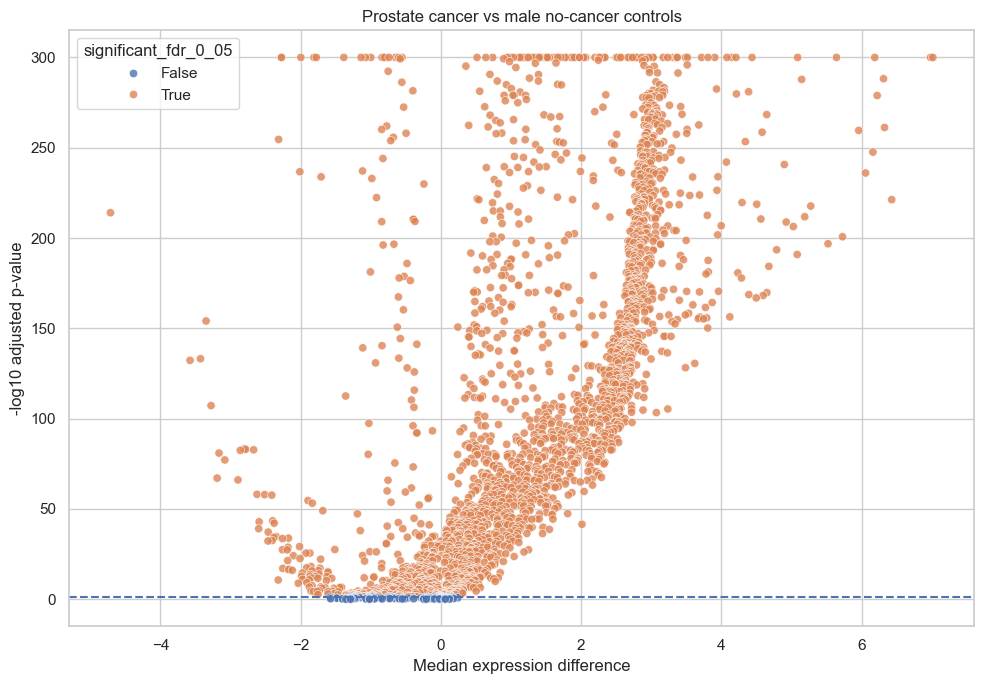

,miRNA,median_diff,rank_biserial,p_value,p_adj
0,hsa-miR-1290,4.150821,-0.982447,0.0,0.0
1,hsa-miR-5100,3.171504,-0.974050,0.0,0.0
2,hsa-miR-17-3p,3.718850,-0.949536,0.0,0.0
3,hsa-miR-8073,2.768220,-0.944875,0.0,0.0
4,hsa-miR-320b,2.790432,-0.923504,0.0,0.0
5,hsa-miR-1228-5p,-0.998260,0.915435,0.0,0.0
6,hsa-miR-1238-5p,2.074258,-0.909645,0.0,0.0
7,hsa-miR-320a,2.339434,-0.906073,0.0,0.0
8,hsa-miR-6741-5p,1.177427,-0.894329,0.0,0.0
9,hsa-miR-342-5p,2.794667,-0.893343,0.0,0.0


In [13]:

if not results_prostate.empty:
    plot_df = results_prostate.copy()
    plot_df["neg_log10_p_adj"] = -np.log10(np.clip(plot_df["p_adj"], 1e-300, None))

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x="median_diff",
        y="neg_log10_p_adj",
        hue="significant_fdr_0_05",
        alpha=0.8
    )
    plt.axhline(-np.log10(0.05), linestyle="--")
    plt.title("Prostate cancer vs male no-cancer controls")
    plt.xlabel("Median expression difference")
    plt.ylabel("-log10 adjusted p-value")
    plt.tight_layout()
    plt.show()

    display(plot_df[["miRNA", "median_diff", "rank_biserial", "p_value", "p_adj"]].head(20))
else:
    print("No results available for plotting.")


## 9) Heatmap of top discriminatory miRNAs

This is often one of the most useful figures to pair with a neural network.


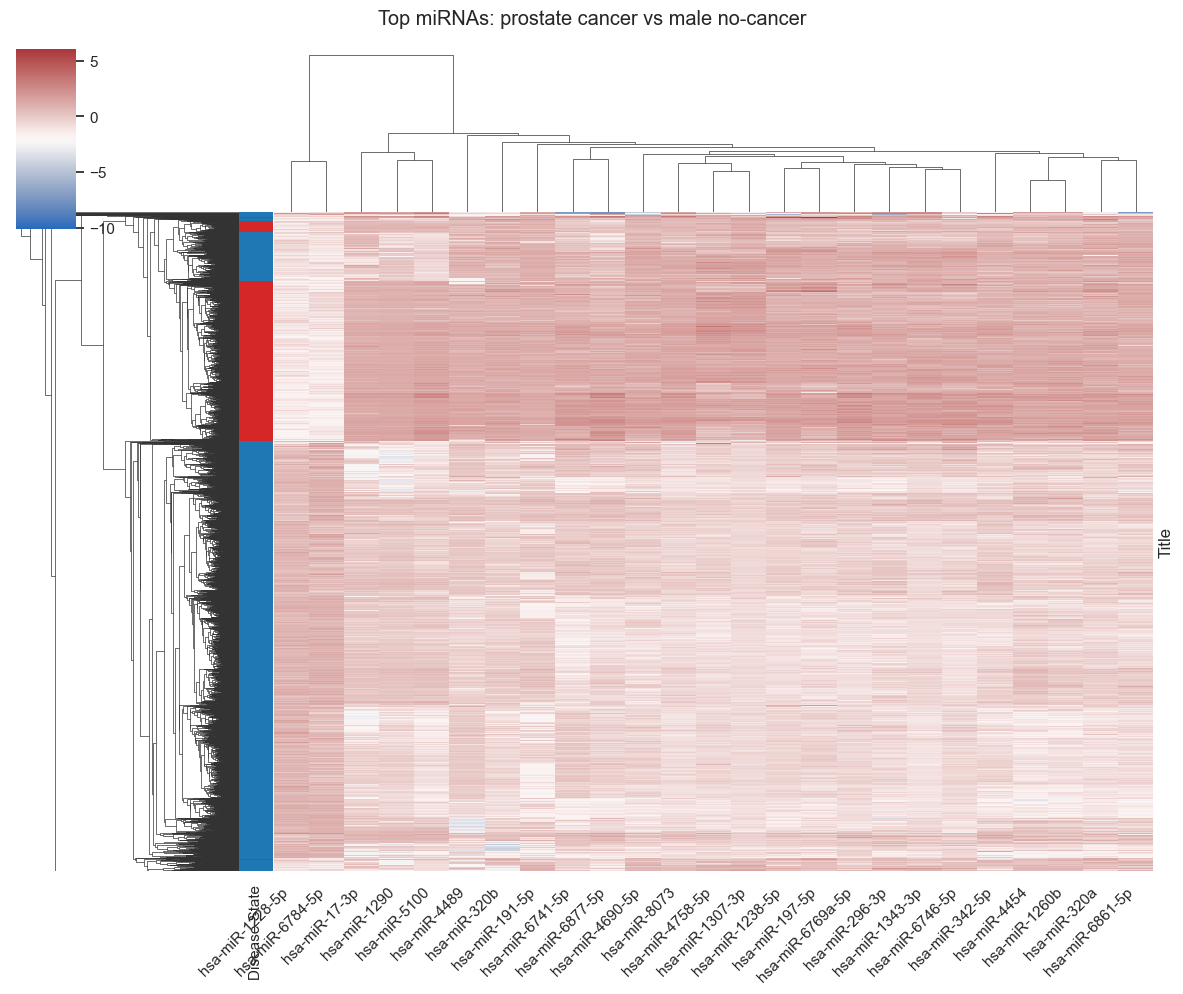

In [14]:

top_n = 25

if not results_prostate.empty:
    top_mirnas = results_prostate.head(top_n)["miRNA"].tolist()

    heatmap_df = merged_df.loc[subset_mask, ["Disease State"] + top_mirnas].copy()
    heatmap_df = heatmap_df[heatmap_df["Disease State"].isin(["prostate cancer", "no cancer"])]

    # Z-score by feature for visualization
    heatmap_values = heatmap_df[top_mirnas].copy()
    heatmap_values = heatmap_values.apply(lambda col: (col - col.mean()) / col.std(ddof=0), axis=0)

    row_colors = heatmap_df["Disease State"].map({
        "prostate cancer": "tab:red",
        "no cancer": "tab:blue"
    })

    cg = sns.clustermap(
        heatmap_values,
        row_colors=row_colors,
        cmap="vlag",
        figsize=(12, 10),
        xticklabels=True,
        yticklabels=False
    )
    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        rotation=45,
        ha="right"
    )
    #cg.ax_row_colors.set_ylabel("Disease State", rotation=45, labelpad=15, va="bottom")
    #cg.fig.subplots_adjust(bottom=0.2)
    plt.suptitle("Top miRNAs: prostate cancer vs male no-cancer", y=1.02)
    #plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No significant features available for heatmap.")


## 10) Boxplots for the top miRNAs
Top **miRNA** sig for prostate cancer

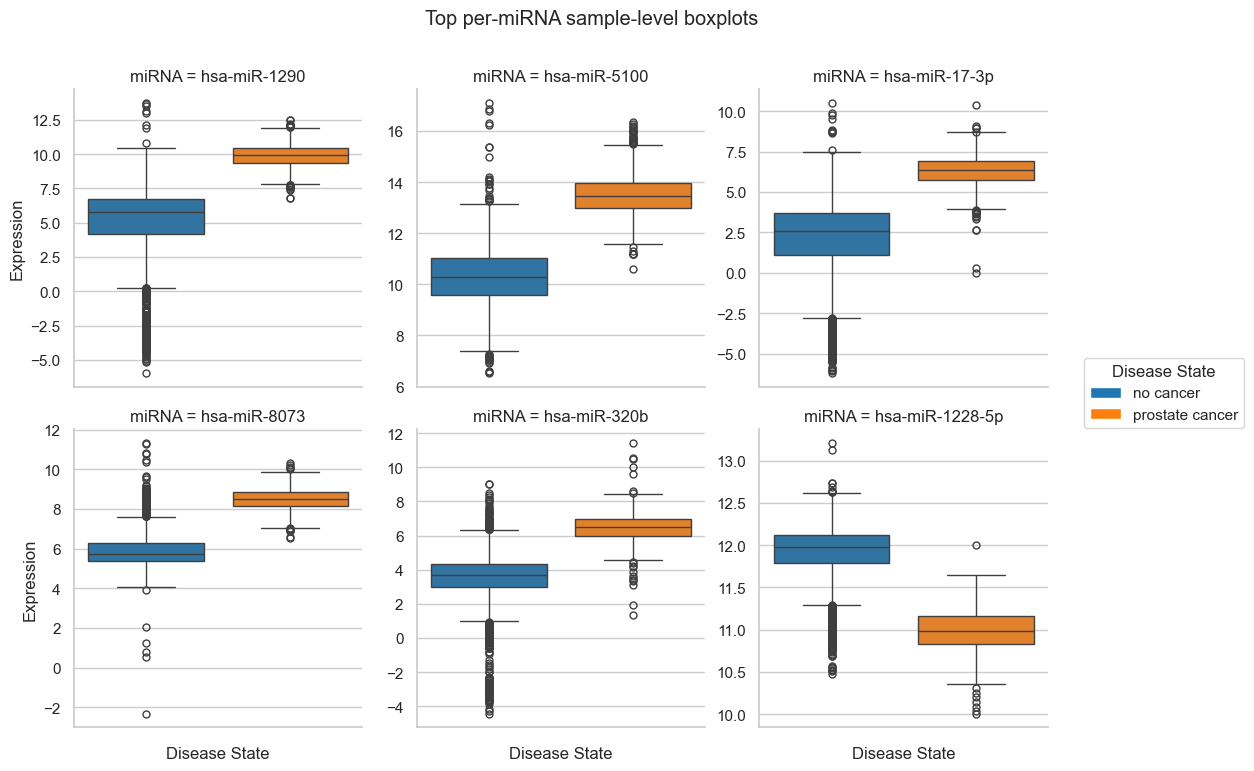

In [23]:
top_k_boxplots = 6

if not results_prostate.empty:
    top_box = results_prostate.head(top_k_boxplots)["miRNA"].tolist()
    plot_data = merged_df.loc[subset_mask, ["Disease State"] + top_box].copy()
    plot_data = plot_data[plot_data["Disease State"].isin(["prostate cancer", "no cancer"])]

    long_box = plot_data.melt(id_vars="Disease State", var_name="miRNA", value_name="Expression")

    palette = {
        "prostate cancer": "tab:orange",
        "no cancer": "tab:blue"
    }

    g = sns.catplot(
        data=long_box,
        x="Disease State",
        y="Expression",
        col="miRNA",
        kind="box",
        hue="Disease State",
        palette=palette,
        col_wrap=3,
        sharey=False,
        height=4,
        legend=False
    )

    g.set_xticklabels(rotation=45)
    g.fig.subplots_adjust(top=0.88, right=0.88)
    g.fig.suptitle("Top per-miRNA sample-level boxplots")

    handles = [
        Patch(facecolor=palette["no cancer"], label="no cancer"),
        Patch(facecolor=palette["prostate cancer"], label="prostate cancer")
    ]

    g.fig.legend(
        handles=handles,
        title="Disease State",
        loc="center right",
        bbox_to_anchor=(1.05, 0.5)
    )

    plt.show()
else:
    print("No results available for boxplots.")

## 11) Looking into statistics for all cancers vs controls

In [37]:
groups = []
for disease, grp in merged_df.dropna(subset=['Age', 'Disease State']).groupby('Disease State'):
    if len(grp) > 1:
        groups.append(grp['Age'].values)
stat, p = kruskal(*groups)
print('Kruskal-Wallis test for age across disease states')
print('Statistic:', stat)
print('p-value:', p)

Kruskal-Wallis test for age across disease states
Statistic: 988.9663534413324
p-value: 4.0939875539817325e-203


```
This tells us that there is a statistically significant difference in age
across all dataset distributions
```

In [47]:
age_df = merged_df[['Age', 'Disease State', 'Gender']].dropna(subset=['Disease State', 'Age']).copy()
control_labels = 'no cancer'
disease_groups = [g for g in age_df['Disease State'].unique() if g != control_labels]

result = []
control_age = age_df[age_df['Disease State'] == control_labels]['Age']
for disease in sorted(disease_groups):
    case_age = age_df.loc[age_df['Disease State'] == disease, 'Age']
    if len(case_age) < 3 or len(control_age) < 3:
        continue
    stat, p = stats.mannwhitneyu(control_age, case_age, alternative='two-sided')
    result.append({
        'comparision': f'{disease} vs {control_labels}',
        'group1': disease,
        'group2': control_labels,
        'n_group1': len(case_age),
        'n_group2': len(control_age),
        'median_group1': case_age.median(),
        'median_group2': control_age.median(),
        'statistic': stat,
        'p_value': p
    })
pairwise_age_results = pd.DataFrame(result)

if not pairwise_age_results.empty:
    pairwise_age_results['p_adj'] = multipletests(pairwise_age_results['p_value'], method='fdr_bh')[1]
    pairwise_age_results = pairwise_age_results.sort_values('p_adj')
pairwise_age_results

,comparision,group1,group2,n_group1,n_group2,median_group1,median_group2,statistic,p_value,p_adj
3,breast cancer vs no cancer,breast cancer,no cancer,672,6267,54.0,70.0,2991493.0,4.624798e-72,6.012237e-71
2,bone and soft tissue sarcomas vs no cancer,bone and soft tissue sarcomas,no cancer,299,6267,49.0,70.0,1392825.0,5.160719e-46,3.354467e-45
10,ovarian cancer vs no cancer,ovarian cancer,no cancer,400,6267,57.0,70.0,1737811.0,1.547251e-38,6.704753e-38
8,intraparenchymal brain tumors vs no cancer,intraparenchymal brain tumors,no cancer,241,6267,58.0,70.0,1025762.5,3.201901e-21,1.040618e-20
4,colorectal cancer vs no cancer,colorectal cancer,no cancer,1596,6267,65.0,70.0,5733036.0,1.523939e-19,3.962241e-19
9,lung cancer vs no cancer,lung cancer,no cancer,1699,6267,66.0,70.0,5899942.0,7.187064e-12,1.557197e-11
11,pancreatic cancer vs no cancer,pancreatic cancer,no cancer,851,6267,65.0,70.0,3033189.0,7.095997e-11,1.317828e-10
6,gastric cancer vs no cancer,gastric cancer,no cancer,1418,6267,66.0,70.0,4913420.5,4.583307e-10,7.447874e-10
5,esophageal squamous cell cancer vs no cancer,esophageal squamous cell cancer,no cancer,566,6267,66.0,70.0,1911051.5,2.215089e-03,3.199574e-03
0,biliary tract cancer vs no cancer,biliary tract cancer,no cancer,402,6267,66.0,70.0,1370018.0,3.181986e-03,4.136582e-03


```
Noticable difference in meidan age for all cancers vs controls
```

In [50]:
sub = merged_df[
    (merged_df["Gender"].eq("Male")) &
    (merged_df["Disease State"].isin(["prostate cancer", "no cancer"]))
][["Disease State", "Age"]].dropna()

age_prostate = sub.loc[sub['Disease State'] == 'prostate cancer', 'Age']
age_control = sub.loc[sub['Disease State'] == 'no cancer', 'Age']
stat, p = stats.mannwhitneyu(age_control, age_prostate, alternative='two-sided')
print('Mann-Whitney U test for age: prostate cancer vs male no-cancer controls')
print('Statistic:', stat)
print('p-value:', p)


Mann-Whitney U test for age: prostate cancer vs male no-cancer controls
Statistic: 1391641.0
p-value: 0.016388019856360746


```
This suggest that there is a small but significant difference in age for the prostate cancer and non-cancer males
```

In [53]:
sub = merged_df[
    (merged_df["Gender"].eq("Female")) &
    (merged_df["Disease State"].isin(["ovarian cancer", "no cancer"]))
][["Disease State", "Age"]].dropna()

age_ovarian = sub.loc[sub['Disease State'] == 'ovarian cancer', 'Age']
age_control = sub.loc[sub['Disease State'] == 'no cancer', 'Age']
stat, p = stats.mannwhitneyu(age_control, age_ovarian, alternative='two-sided')
print('Mann-Whitney U test for age: ovarian cancer vs female no-cancer controls')
print('Statistic:', stat)
print('p-value:', p)


Mann-Whitney U test for age: ovarian cancer vs female no-cancer controls
Statistic: 983812.5
p-value: 2.0551245337124654e-47


```
This suggest that there is a statistically significant difference in the age of individuals diagnoised with Ovarian cancer and the female controls
```